This notebook explores the relationship between the the accuracy of models compared to the subject of the query's internet presence.

In [39]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [40]:
# Configuration: Specify models to compare
models_config = [
    {
        "model": "gpt-oss-20b-off",
        "eval_model": "gpt-oss-20b-entailment",
        "run_prefix": "exp-1",
        "label": "gpt-oss-20b-off",  # Optional: custom label for legend
        "color": "#2E86AB" 
    },

    {
        "model": "gpt-oss-20b-medium",
        "eval_model": "gpt-oss-20b-entailment",
        "run_prefix": "exp-1",
        "label": "gpt-oss-20b-medium",
        "color": "#06A77D" 
    },

    # {
    #     "model": "qwen3-8b-no-thinking",
    #     "eval_model": "gpt-oss-20b-entailment",
    #     "run_prefix": "exp-1",
    #     "label": "qwen3-8b-no-thinking",
    #     "color": "#D62828" 
    # },

    # {
    #     "model": "qwen3-8b-thinking",
    #     "eval_model": "gpt-oss-20b-entailment",
    #     "run_prefix": "exp-1",
    #     "label": "qwen3-8b-thinking",
    #     "color": "#F77F00" 
    # }
]

In [ ]:
def is_accurate(label: str, entailment: str) -> bool:
    """Check if entailment matches the expected label."""
    if label == "SUPPORTS" and entailment == "agree":
        return True
    elif label == "REFUTES" and entailment == "disagree":
        return True
    elif entailment == "neutral":
        return True
    return False


def load_model_data(model: str, eval_model: str, run_prefix: str):
    """Load and process data for a single model."""
    file_path = os.path.abspath("")
    base_path = f"{file_path}/../results/{run_prefix}/foolmetwice/{model}"
    
    # Load data
    generations = pd.read_json(f"{base_path}/generations.jsonl", lines=True)
    entailment = pd.read_json(f"{base_path}/evaluation_{eval_model}.jsonl", lines=True)
    dataset = pd.read_json(f"{file_path}/data/train_keywords.jsonl", lines=True)
    
    # Merge generations and entailment
    evaluations = generations.merge(
        entailment,
        left_on="gen_id",
        right_on="gen_id",
        suffixes=("_gen", "_eval"),
    )
    
    # Build pivot of entailments per base query id and level
    eval_df = evaluations[["query_id", "entailment"]].copy()
    eval_df[["base_id", "level"]] = eval_df['query_id'].str.rsplit('_', n=1, expand=True)
    eval_df['level'] = eval_df['level'].astype(int)
    pivot = eval_df.pivot(index='base_id', columns='level', values='entailment')
    pivot = pivot.reindex(columns=range(5))
    
    # Merge pivoted entailments into dataset
    merged = dataset.merge(pivot, how='left', left_on='id', right_index=True)
    
    # Compute accuracy mask for each level (vectorized)
    accurate_cols = []
    for lvl in range(5):
        col = merged[lvl]
        accurate = ( (merged['label'] == 'SUPPORTS') & (col == 'agree') ) | \
                   ( (merged['label'] == 'REFUTES') & (col == 'disagree') ) | \
                   ( col == 'neutral' )
        accurate_cols.append(accurate.fillna(False).values)
    
    # Stack into 2D boolean array: rows x levels
    accurate_arr = np.column_stack(accurate_cols)
    
    return dataset, accurate_arr


def compute_accuracy_vs_frequency(dataset, accurate_arr, n_bins=20):
    """Compute binned accuracy vs google count."""
    # Find google count column
    possible_cols = ['google_count', 'google_hits', 'google_results', 'google_count_total', 'google']
    gc_col = next((c for c in possible_cols if c in dataset.columns), None)
    
    if gc_col is None:
        raise ValueError(f"No google-count column found in dataset. Available: {list(dataset.columns)}")
    
    # Create a dataframe with one row per query-level combination
    query_level_data = []
    for idx, row in dataset.iterrows():
        gc = row[gc_col]
        
        # Get accuracy for each presupposition level (0-4)
        for lvl in range(5):
            is_acc = accurate_arr[idx, lvl]
            query_level_data.append({
                'google_count': gc,
                'is_accurate': int(is_acc),
            })
    
    df_all = pd.DataFrame(query_level_data)
    df_all['google_count'] = df_all['google_count'].fillna(0).astype(float)
    
    # Binned means (quantile bins on google count)
    uniq = df_all['google_count'].nunique()
    n_bins = min(n_bins, uniq)
    df_all['gc_bin'] = pd.qcut(df_all['google_count'].rank(method='first'), q=n_bins, duplicates='drop')
    
    bin_stats = df_all.groupby('gc_bin').agg(
        median_gc=('google_count', 'median'), 
        mean_accuracy=('is_accurate', 'mean')
    )
    bin_stats = bin_stats.dropna()
    bin_stats['mean_accuracy_pct'] = bin_stats['mean_accuracy'] * 100
    
    bin_x = np.log10(bin_stats['median_gc'].values)
    bin_y = bin_stats['mean_accuracy_pct'].values
    
    overall_accuracy = df_all["is_accurate"].mean() * 100
    
    return bin_x, bin_y, overall_accuracy, len(df_all)

In [42]:
# Process all models and collect results
results = []

for config in models_config:
    model = config["model"]
    eval_model = config["eval_model"]
    run_prefix = config["run_prefix"]
    label = config.get("label", model)
    color = config.get("color", None)
    
    print(f"Processing {model}...")
    
    try:
        dataset, accurate_arr = load_model_data(model, eval_model, run_prefix)
        bin_x, bin_y, overall_acc, n_points = compute_accuracy_vs_frequency(dataset, accurate_arr, n_bins=10)
        
        results.append({
            "label": label,
            "color": color,
            "bin_x": bin_x,
            "bin_y": bin_y,
            "overall_accuracy": overall_acc,
            "n_points": n_points
        })
        
        print(f"  ✓ Overall accuracy: {overall_acc:.2f}% ({n_points} data points)")
    except Exception as e:
        print(f"  ✗ Error: {e}")

print(f"\nSuccessfully loaded {len(results)} models.")

Processing gpt-oss-20b-off...


C:\Users\vsros\AppData\Local\Temp\ipykernel_16740\1161671125.py:85: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_stats = df_all.groupby('gc_bin').agg(


  ✓ Overall accuracy: 71.24% (52090 data points)
Processing gpt-oss-20b-medium...
  ✓ Overall accuracy: 72.89% (52090 data points)

Successfully loaded 2 models.
  ✓ Overall accuracy: 72.89% (52090 data points)

Successfully loaded 2 models.


C:\Users\vsros\AppData\Local\Temp\ipykernel_16740\1161671125.py:85: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_stats = df_all.groupby('gc_bin').agg(


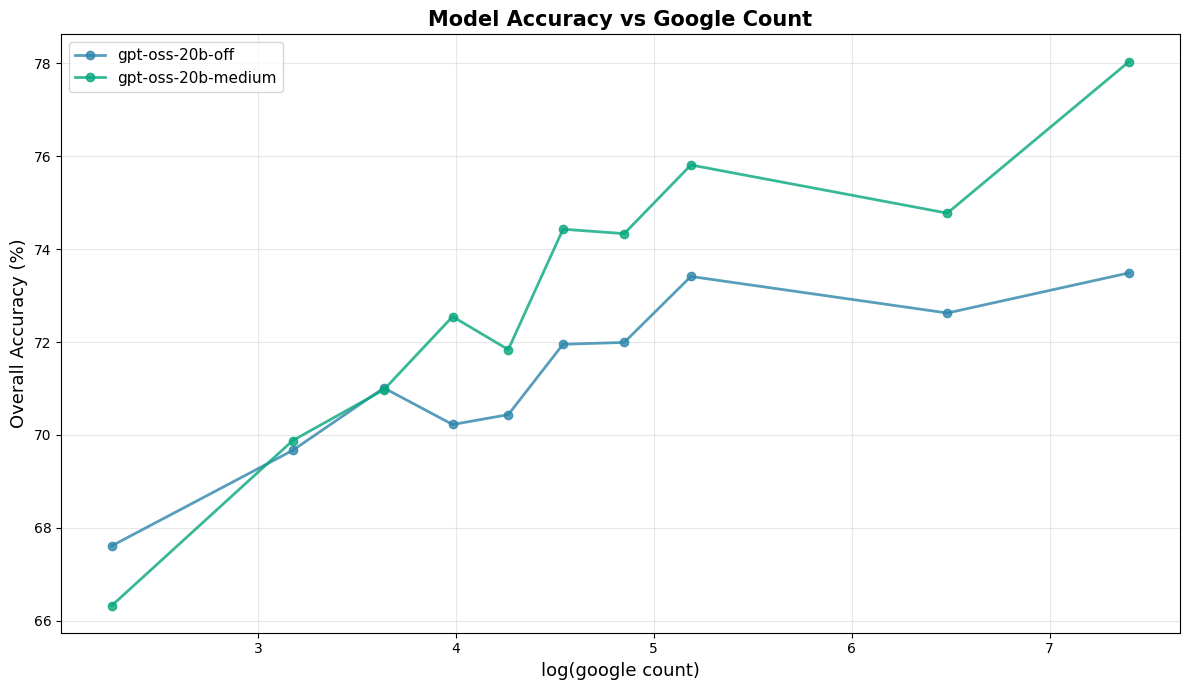


SUMMARY STATISTICS
gpt-oss-20b-off               :  71.2% (n=52,090)
gpt-oss-20b-medium            :  72.9% (n=52,090)


In [43]:
# Plot all models on the same graph
plt.figure(figsize=(12, 7))

# Default colors if not specified
default_colors = ['steelblue', 'coral', 'mediumseagreen', 'orchid', 'goldenrod', 'crimson', 'teal']

for i, result in enumerate(results):
    color = result["color"] if result["color"] else default_colors[i % len(default_colors)]
    label = result["label"]
    
    plt.plot(result["bin_x"], result["bin_y"], 
             color=color, 
             marker='o', 
             linewidth=2, 
             markersize=6,
             label=label,
             alpha=0.8)

plt.xlabel('log(google count)', fontsize=13)
plt.ylabel('Overall Accuracy (%)', fontsize=13)
plt.title('Model Accuracy vs Google Count', fontsize=15, fontweight='bold')
# plt.ylim(0, 105)
plt.grid(alpha=0.3)
plt.legend(fontsize=11, loc='best')
plt.tight_layout()
plt.show()

# Print summary statistics
print("\n" + "="*70)
print("SUMMARY STATISTICS")
print("="*70)
for result in results:
    print(f"{result['label']:30s}: {result['overall_accuracy']:5.1f}% (n={result['n_points']:,})")
print("="*70)